In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("laptops_dataset_final_600.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24113 entries, 0 to 24112
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    24113 non-null  object 
 1   overall_rating  24113 non-null  float64
 2   no_ratings      24113 non-null  object 
 3   no_reviews      24113 non-null  object 
 4   rating          24113 non-null  int64  
 5   title           24113 non-null  object 
 6   review          24113 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.3+ MB


# Data Preprocessing

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_review'] = df['review'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
df['cleaned_review'] = df['review'].apply(clean_text)

df[['review', 'cleaned_review']].head()


,review,cleaned_review
0,"Loved it, it's my first MacBook that I earned ...",loved first macbook earned hardwork
1,Battery lasted longer than my first relationsh...,battery lasted longer first relationship day l...
2,Such a great deal.. very happy with the perfor...,great deal happy performance battery life orig...
3,"Awesome build quality and very good display, b...",awesome build quality good display battery cam...
4,When i ordered and came to know about seller r...,ordered came know seller review scared conditi...


In [14]:
df.columns

Index(['product_name', 'overall_rating', 'no_ratings', 'no_reviews', 'rating',
       'title', 'review', 'cleaned_review'],
      dtype='object')

# Convert Text → Numerical Format

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['cleaned_review'])


# Model Implementation

In [22]:
def convert_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['rating'].apply(convert_sentiment)

df[['rating', 'Sentiment']].head()


,rating,Sentiment
0,5,Positive
1,5,Positive
2,5,Positive
3,4,Positive
4,5,Positive


In [24]:
df['Sentiment'].value_counts()


Sentiment
Positive    19601
Negative     2477
Neutral      2035
Name: count, dtype: int64

In [26]:
y = df['Sentiment']


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       0.84      0.77      0.81       507
     Neutral       0.68      0.22      0.33       376
    Positive       0.92      0.99      0.96      3940

    accuracy                           0.91      4823
   macro avg       0.81      0.66      0.70      4823
weighted avg       0.89      0.91      0.89      4823



# Visualization
# Sentiment Distribution

In [33]:
import matplotlib.pyplot as plt

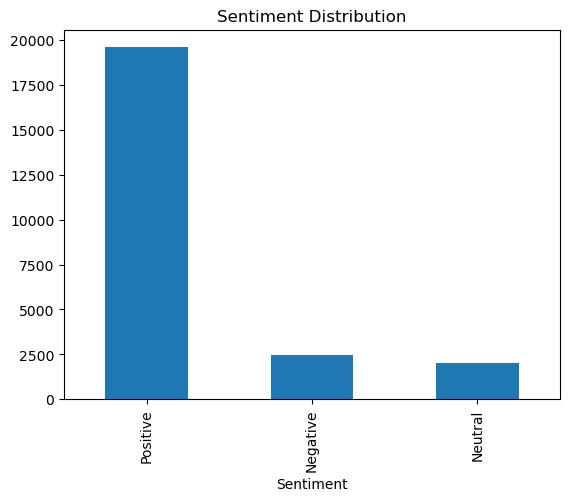

In [35]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

# Logistic Regression model achieved high accuracy in classifying customer reviews into sentiment categories. Text preprocessing and TF-IDF vectorization significantly improved model performance. The analysis helps businesses understand customer satisfaction trends and areas of improvement.

# Naive Bayes Model (Second Model)

In [47]:
from sklearn.naive_bayes import MultinomialNB


In [49]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.872900684221439
              precision    recall  f1-score   support

    Negative       0.90      0.49      0.63       507
     Neutral       0.84      0.08      0.15       376
    Positive       0.87      1.00      0.93      3940

    accuracy                           0.87      4823
   macro avg       0.87      0.52      0.57      4823
weighted avg       0.87      0.87      0.84      4823



# Compare Two Model

In [54]:
lr_accuracy = accuracy_score(y_test, y_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)


Logistic Regression Accuracy: 0.9079411154882853
Naive Bayes Accuracy: 0.872900684221439


# WordCloud

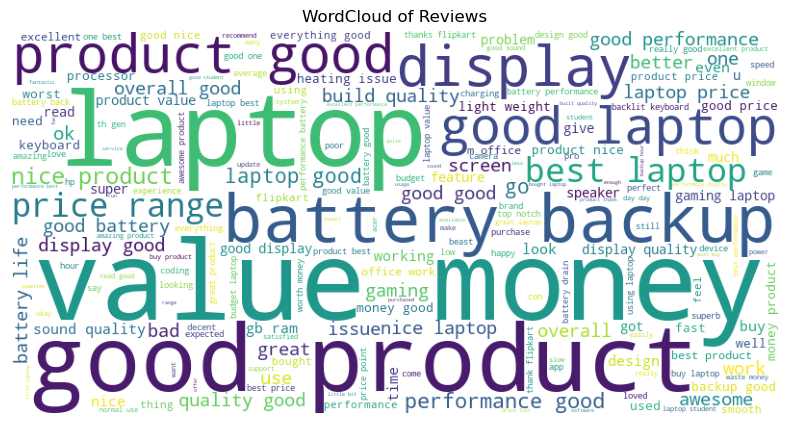

In [56]:
from wordcloud import WordCloud

text = " ".join(df['cleaned_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud of Reviews")
plt.show()


In [59]:
positive_text = " ".join(df[df['Sentiment']=="Positive"]['cleaned_review'])
negative_text = " ".join(df[df['Sentiment']=="Negative"]['cleaned_review'])


# Insights

# Positive reviews frequently mention words like good, excellent, fast, smooth

# Negative reviews frequently mention words like battery, heating, issue, problem